In [101]:
import MDAnalysis as mda

In [102]:
import numpy as np
import pandas as pd
import seaborn as sb
from MDAnalysis.analysis import density
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import rc


cbar.ax.set_yticklabels(ticklabs, fontsize=25)
ticklabs = cbar.ax.get_yticklabels()
hfont = {'fontname':'Helvetica','fontweight':'bold'}
rc('text', usetex=True)
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']}) 

%matplotlib inline

NameError: name 'ticklabs' is not defined

In [117]:
u = mda.Universe("final-503l.gro")

In [118]:
print(u)

<Universe with 369949 atoms>


In [119]:
pi = u.select_atoms('resname CHL1')

In [120]:
dens = density.DensityAnalysis(pi, delta=4.0,padding=2)
dens.run()

/home/unmesh/anaconda3/lib/python3.7/site-packages/MDAnalysis/coordinates/base.py:892: UserWarning: Reader has no dt information, set to 1.0 ps
  warnings.warn("Reader has no dt information, set to 1.0 ps")


In [121]:
grid = dens.density.grid
grid.shape

(50, 75, 13)

In [122]:
#dens.density.convert_density('nm^{-3}'
dens.density.convert_length("nm")

In [123]:
dens.density.convert_density('nm^{-3}')

In [124]:
dens.density.units


{'length': 'nm', 'density': 'nm^{-3}'}

In [125]:
mx, my, mz = dens.density.midpoints

In [126]:
grid = dens.density.grid
flat = grid.ravel() / (grid.max()*10)

In [127]:
blue = [44, 130, 201, 1]
colors = [blue] * len(mx) * len(my) * len(mz)
colors = np.array(colors, dtype=float)
colors[:, -1] *= flat
colors[:, :3] /= 255

In [128]:
avg = grid.mean(axis=-1)
avg.shape

(50, 75)

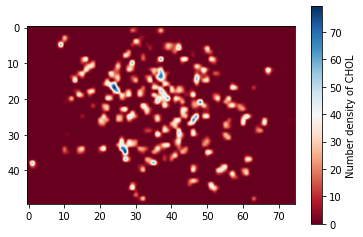

In [129]:
fig, ax = plt.subplots()

im = ax.imshow(avg,interpolation='spline16',cmap=cm.RdBu)
cbar = plt.colorbar(im)
cbar.set_label('Number density of CHOL')

#plt.xlabel('X-axis (nm)',fontsize=25)
#plt.ylabel('Y-axis ($\AA$)',fontsize=25);
#plt.xlabel(x_l,fontsize=25)
#plt.ylabel(y_l,fontsize=25)
plt.xticks(None)
plt.yticks(None)
plt.savefig('density-chol.png')
